### 1. Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### 2. Load Dataset 

In [33]:
df = pd.read_csv(r"retail_sales.csv")
df.head()

,Age (bin),Age Group,Category,Color,Discount,Discount Count,Frequency of Purchases,Gender,Item,Location,...,Shipping Type,Size,Subscription Status,Table Name,Age,Customer,Previous Purchases,Product Count,Review Rating,Sales (USD)
0,50,55-64,Clothing,Gray,Yes,1,Fortnightly,Male,Blouse,Kentucky,...,Courier,L,No,Retail_Clothing_Sales.csv,55,1,6,1,3.1,39.94
1,10,18-24,Clothing,Maroon,Yes,1,Fortnightly,Male,Sweater,Maine,...,Courier,L,No,Retail_Clothing_Sales.csv,19,2,1,1,3.1,58.23
2,50,45-54,Clothing,Maroon,Yes,1,Weekly,Male,Jeans,Massachusetts,...,Courier,S,No,Retail_Clothing_Sales.csv,50,3,3,1,3.1,80.19
3,20,18-24,Footwear,Maroon,Yes,1,Weekly,Male,Sandals,Rhode Island,...,Store Pickup,M,No,Retail_Clothing_Sales.csv,21,4,0,1,3.5,168.40
4,40,45-54,Clothing,Turquoise,Yes,1,Fortnightly,Male,Blouse,Oregon,...,Courier,M,No,Retail_Clothing_Sales.csv,45,5,1,1,2.7,34.43


### 3. Data Overview

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age (bin)               3900 non-null   int64  
 1   Age Group               3900 non-null   object 
 2   Category                3900 non-null   object 
 3   Color                   3900 non-null   object 
 4   Discount                3900 non-null   object 
 5   Discount Count          3900 non-null   int64  
 6   Frequency of Purchases  3900 non-null   object 
 7   Gender                  3900 non-null   object 
 8   Item                    3900 non-null   object 
 9   Location                3900 non-null   object 
 10  Past Purchases          3900 non-null   object 
 11  Payment Method          3900 non-null   object 
 12  Season                  3900 non-null   object 
 13  Shipping Type           3900 non-null   object 
 14  Size                    3900 non-null   

In [35]:
df.describe()

,Age (bin),Discount Count,Age,Customer,Previous Purchases,Product Count,Review Rating,Sales (USD)
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.0,3900.000000,3900.000000
mean,30.510256,0.430000,34.910000,1947.798462,2.228718,1.0,3.749949,86.189372
std,13.397896,0.495139,12.760157,1126.099012,2.380242,0.0,0.716223,110.847694
min,10.000000,0.000000,18.000000,1.000000,0.000000,1.0,2.500000,9.000000
25%,20.000000,0.000000,25.000000,975.750000,0.000000,1.0,3.100000,23.397500
50%,30.000000,0.000000,32.000000,1949.500000,2.000000,1.0,3.700000,48.825000
75%,40.000000,1.000000,41.000000,2925.250000,4.000000,1.0,4.400000,105.635000
max,70.000000,1.000000,70.000000,3900.000000,9.000000,1.0,5.000000,1281.240000


### 4. Distribution By Sales

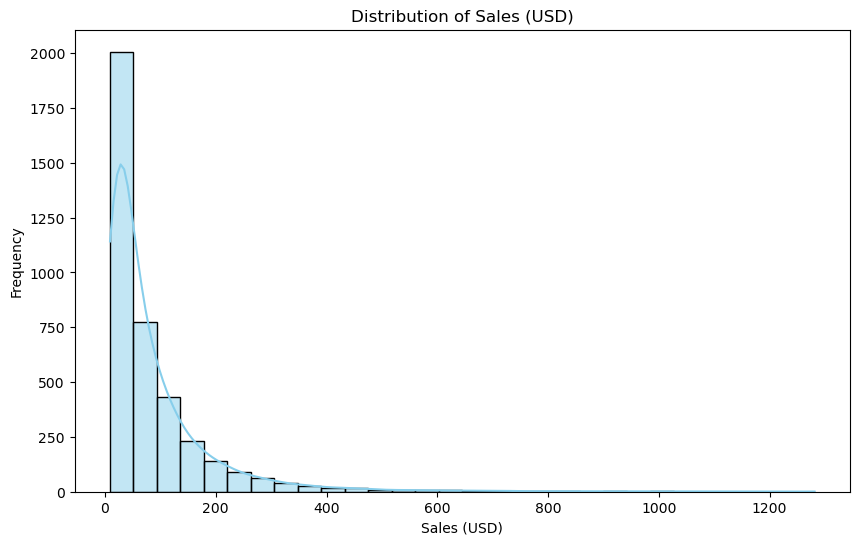

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales (USD)'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Sales (USD)')
plt.xlabel('Sales (USD)')
plt.ylabel('Frequency')
plt.show()

### 5. Distribution By Age

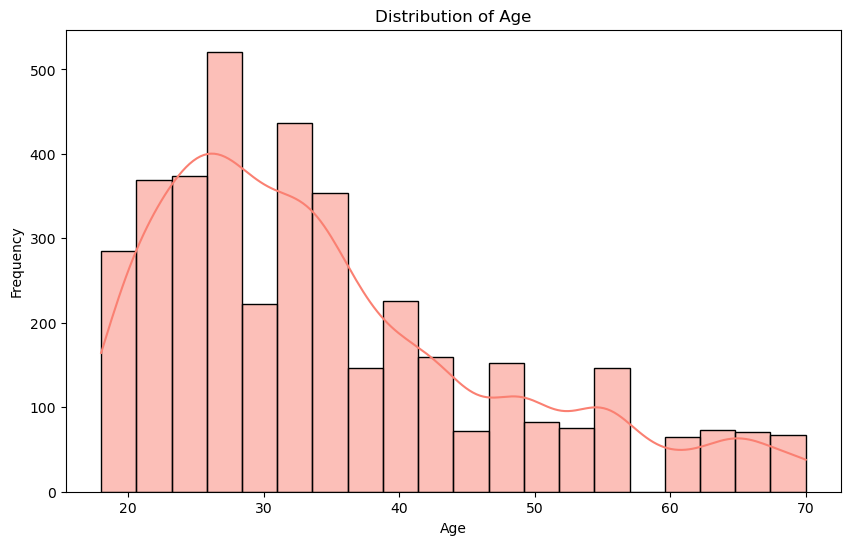

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### 6. Transactions

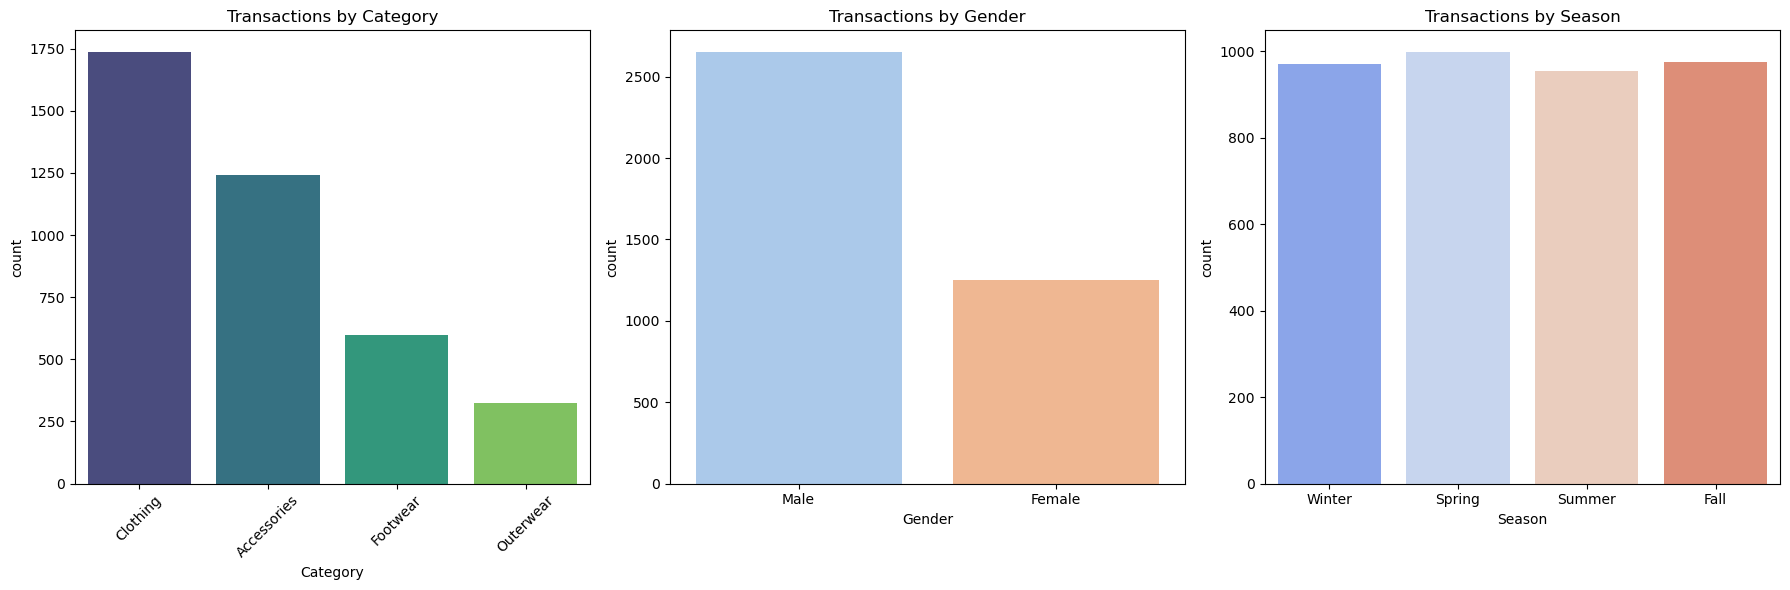

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=df, x='Category', ax=axes[0], palette='viridis', order=df['Category'].value_counts().index)
axes[0].set_title('Transactions by Category')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Gender', ax=axes[1], palette='pastel')
axes[1].set_title('Transactions by Gender')

sns.countplot(data=df, x='Season', ax=axes[2], palette='coolwarm')
axes[2].set_title('Transactions by Season')

plt.tight_layout()
plt.show()

### 7. Average Sales

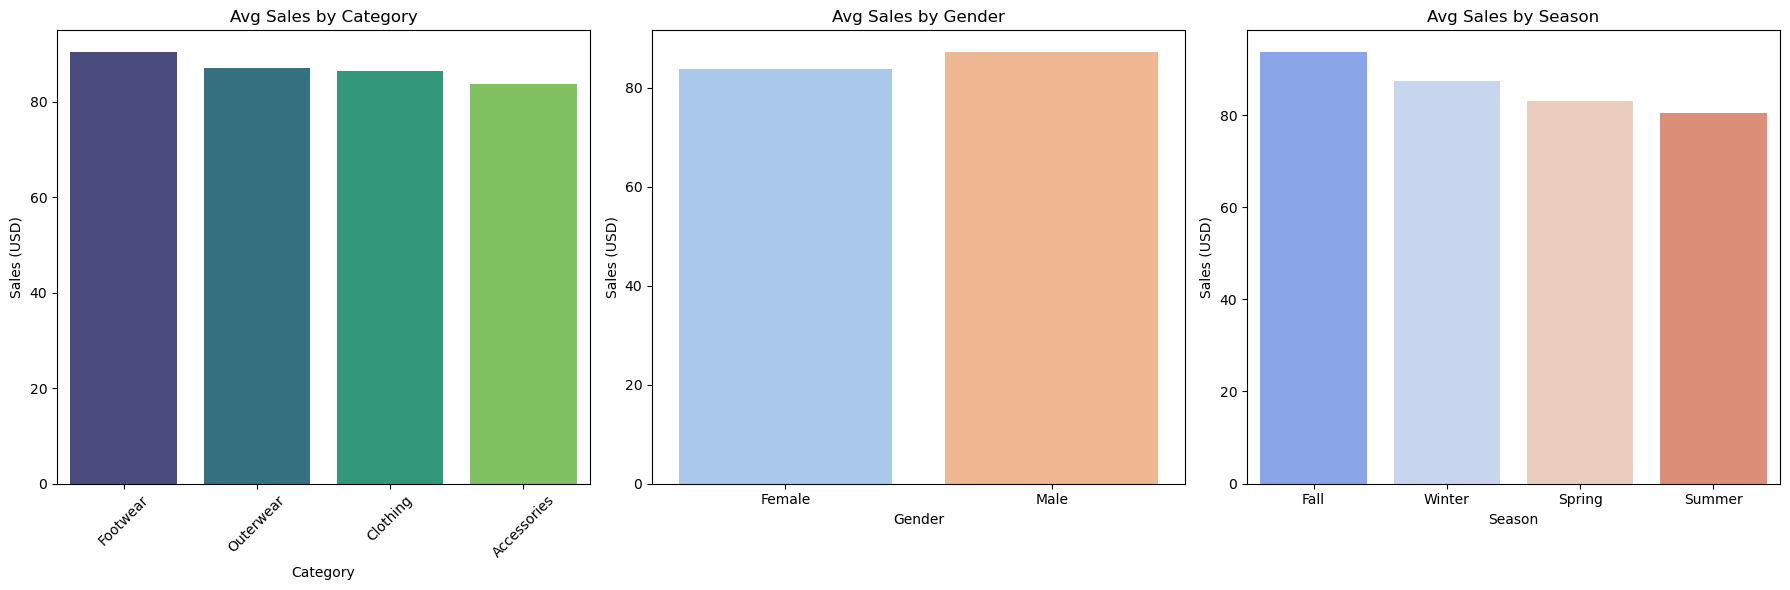

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Avg Sales by Category
avg_sales_cat = df.groupby('Category')['Sales (USD)'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_sales_cat, x='Category', y='Sales (USD)', ax=axes[0], palette='viridis')
axes[0].set_title('Avg Sales by Category')
axes[0].tick_params(axis='x', rotation=45)

# Avg Sales by Gender
avg_sales_gender = df.groupby('Gender')['Sales (USD)'].mean().reset_index()
sns.barplot(data=avg_sales_gender, x='Gender', y='Sales (USD)', ax=axes[1], palette='pastel')
axes[1].set_title('Avg Sales by Gender')

# Avg Sales by Season
avg_sales_season = df.groupby('Season')['Sales (USD)'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_sales_season, x='Season', y='Sales (USD)', ax=axes[2], palette='coolwarm')
axes[2].set_title('Avg Sales by Season')

plt.tight_layout()
plt.show()

### 8. Top 10 Items By Sales

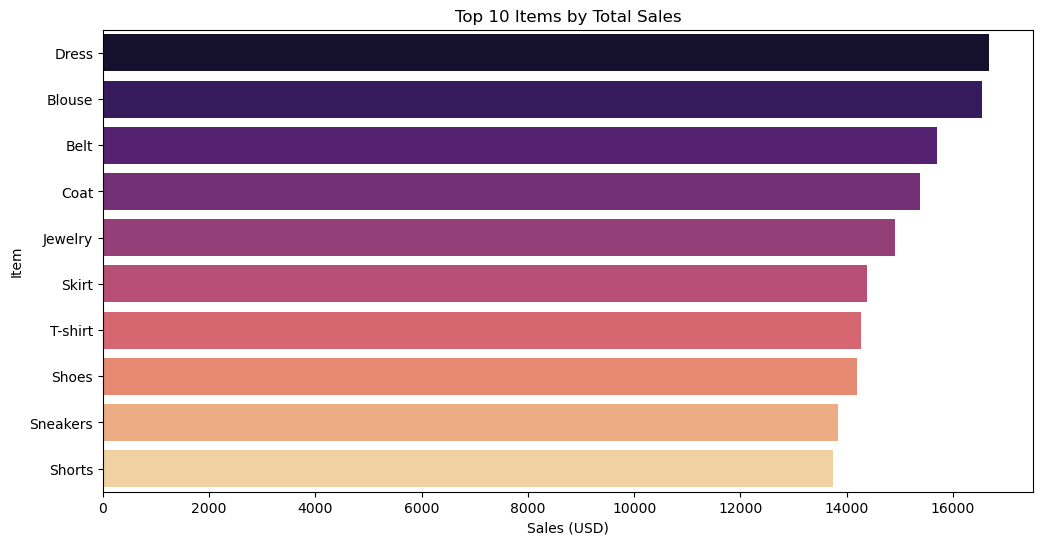

In [42]:
top_items = df.groupby('Item')['Sales (USD)'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_items, x='Sales (USD)', y='Item', palette='magma')
plt.title('Top 10 Items by Total Sales')
plt.show()


### 9. Top 10 Locations By Sales

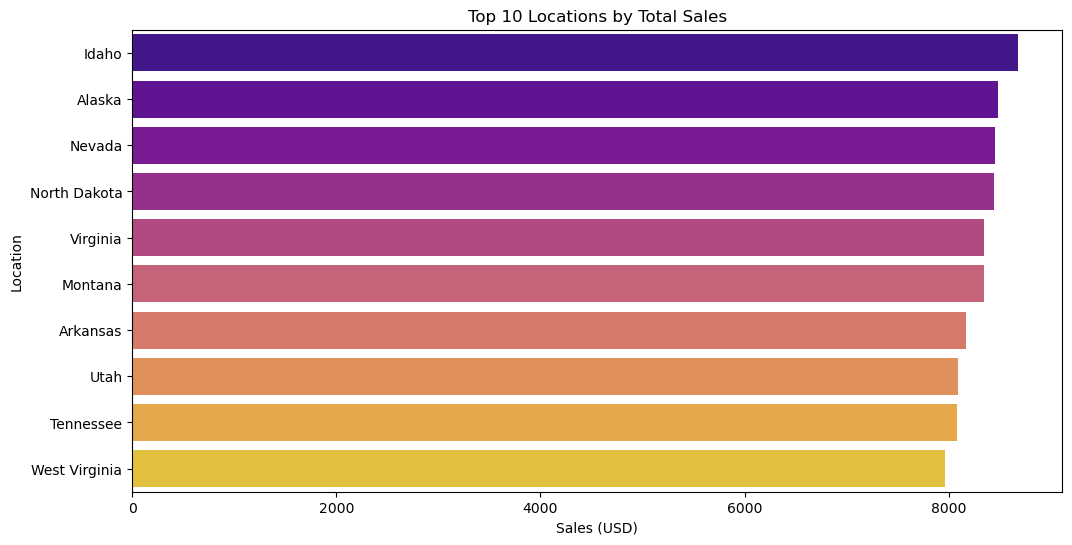

In [41]:
# Top 10 Locations
top_locations = df.groupby('Location')['Sales (USD)'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_locations, x='Sales (USD)', y='Location', palette='plasma')
plt.title('Top 10 Locations by Total Sales')
plt.show()